In [1]:
!pip install --upgrade -q accelerate bitsandbytes transformers==4.48.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.7/354.7 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 72.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is

In [2]:
!python --version

Python 3.11.11


In [3]:
import os
import math
import requests
import json
import torch
import random
import cv2
import nltk

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torch.nn import functional as F


In [4]:
image_path = "/kaggle/input/coco-train-sample-5000/samples/images/"
image_files = os.listdir(image_path)
print(len(image_files), image_files[0])

5000 COCO_train2014_000000351298.jpg


In [5]:
def get_one_image(idx=-1,
                  image_path="/kaggle/input/coco-train-sample-5000/samples/images/"):
    image_files = sorted(os.listdir(image_path))
    data_size = len(image_files)
    assert(idx >=- 1 and idx < data_size)
    if idx < 0:
        idx = random.randint(1, data_size)-1
    print(f"choose index {idx} from total {data_size} images")
    img_path = image_path + image_files[idx]
    img_id = int(image_files[idx].split("_")[-1][:-4])
    image = Image.open(img_path)
    np_image = np.asarray(image)
    return np_image, str(img_id)

def get_captions(caption_file="/kaggle/input/coco-train-sample-5000/samples/captions.json"):
    with open(caption_file, 'r') as f:
        captions = json.load(f)
    return captions

def get_img_captions(img_id, captions):
    return captions[img_id]

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [7]:
from transformers import AutoProcessor, LlavaForConditionalGeneration
from transformers import BitsAndBytesConfig

2025-04-24 17:58:31.038314: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745517511.221437      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745517511.275808      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [8]:
def load_llava(model_name_or_path,
               device_map="auto",
               quantization = True):

    quantization_config = BitsAndBytesConfig(
        load_in_4bit=quantization,
        bnb_4bit_compute_dtype=torch.float16
    )
    
    processor = AutoProcessor.from_pretrained(model_name_or_path)
    tokenizer = processor.tokenizer
    model = LlavaForConditionalGeneration.from_pretrained(model_name_or_path,
                                                          device_map=device_map,
                                                          quantization_config=quantization_config)
    return model, tokenizer, processor


def get_llava_image_features(model, processor, image):
    inputs = processor(images=image, text="", return_tensors="pt").to(model.device, torch.float16)
    image_features = model.get_image_features(
        pixel_values=inputs.pixel_values,
        vision_feature_layer=model.config.vision_feature_layer,
        vision_feature_select_strategy=model.config.vision_feature_select_strategy
    )
    return image_features


def get_llava_logits(image_feature = None,
                     model=None,
                     tokenizer = None,
                     image_token = None):
        
    batch, _, _ = image_feature.shape
    prompt_strings = [image_token]*batch
    text_inputs = tokenizer(prompt_strings, return_tensors="pt")
    input_ids = text_inputs["input_ids"]
        
    inputs_embeds = model.get_input_embeddings()(input_ids)
    inputs_embeds, attention_mask, labels, position_ids = model._merge_input_ids_with_image_features(image_feature, 
                                                                            inputs_embeds, 
                                                                            input_ids, 
                                                                            text_inputs.attention_mask, 
                                                                            labels=None)

    outputs = model.language_model(
        attention_mask=attention_mask,
        position_ids=position_ids,
        inputs_embeds=inputs_embeds,
    )
    logits = outputs[0]
    return logits

In [9]:
model, tokenizer, processor = load_llava(model_name_or_path="llava-hf/llava-1.5-7b-hf",
                                            device_map="auto",
                                            quantization = True)

processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json:   0%|          | 0.00/1.45k [00:00<?, ?B/s]

...

model-00001-of-00003.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.18G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

In [10]:
data_size = len(os.listdir(image_path))

projection_layer = model.language_model.lm_head

captions = get_captions()

prompt = "USER: <image>\n describe the image ASSISTANT:" 

generate_config = {
    "return_dict_in_generate": True,
    "output_attentions": True,
    "output_hidden_states": True,
}

In [11]:
def get_probs(input_kwargs, obj_token_ids):
    outputs = model.generate(**input_kwargs, max_new_tokens=1)
    hidden_states = torch.stack(outputs.hidden_states[0])[:,:,5:5+576,:]

    with torch.inference_mode():
        logits = projection_layer(hidden_states).cpu()
        prob = F.softmax(logits, dim=-1).detach().cpu().numpy()
        internal_conf_heatmap = np.max(prob[:,:,:, obj_token_ids], axis=-1).squeeze()

    probs = np.max(internal_conf_heatmap, axis=0)
    return probs

In [12]:
def plot_bbox(img_np, bbox, label):
    fig, ax = plt.subplots(1)
    x_lt = bbox[0]
    y_lt = bbox[1]
    x_rt = x_lt + bbox[2]
    y_rt = y_lt
    x_rb = x_lt + bbox[2]
    y_rb = y_lt + bbox[3]
    x_lb = x_lt
    y_lb = y_lt + bbox[3]
    
    ax.imshow(img_np)
    plt.plot([x_lt, x_rt, x_rb, x_lb, x_lt], [y_lt, y_rt, y_rb, y_lb, y_lt], color='red', linewidth=1.5)
    ax.text(x_lt, y_lt-10, label, color='red', fontsize=12)
    ax.set_axis_off()

choose index 2455 from total 5000 images


`torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to eager attention. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.
From v4.47 onwards, when a model cache is to be returned, `generate` will return a `Cache` instance instead by default (as opposed to the legacy tuple of tuples format). If you want to keep returning the legacy format, please set `return_legacy_cache=True`.


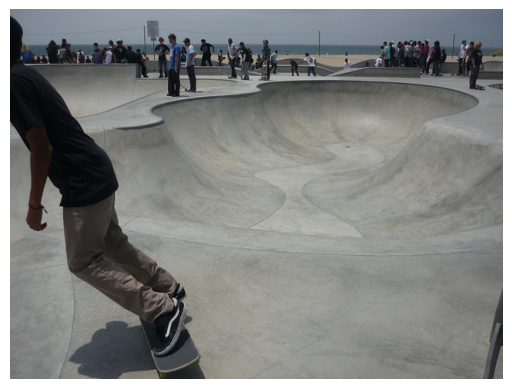

In [13]:
img_np, img_id = get_one_image(idx=-1)

height, width, _ = img_np.shape

fig, ax = plt.subplots(1)
ax.imshow(img_np)
ax.set_axis_off()

inputs = processor(images=img_np, text=prompt, return_tensors="pt").to(model.device, torch.float16)
input_kwargs = {**inputs, **generate_config}
outputs = model.generate(**input_kwargs, max_new_tokens=1)

In [14]:
print(captions[img_id])

{'captions': ['A skateboarder is riding the ramps at a skate park.', 'A group of people skate boarding in a skate park.', 'A bunch of people hanging out at a skate park while a boy skateboards. ', 'A park with a skateboarder up close and some skateboarders in the background. ', 'A young man skateboarding at a skate park.'], 'categories': ['skateboard', 'skateboard', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'skateboard', 'person', 'person', 'person', 'skateboard', 'person'], 'bboxes': [[172.58, 404.49, 72.27, 69.04], [602.79, 97.77, 14.99, 8.9], [0.17, 8.17, 253.81, 471.66], [200.64, 30.48, 23.23, 85.18], [225.8, 38.79, 16.66, 70.21], [245.97, 38.72, 20.58, 35.52], [282.92, 37.72, 15.53, 52.52], [296.98, 41.78, 14.29, 50.78], [318.57, 58.4, 8.29, 19.22], [321.38, 39.88, 17.3, 53.24], [336.99, 51.74, 11.21, 32.03], [597.46, 41.79, 19.2, 64.37], [583.23, 67.48, 9.2, 21.4], [269.27, 52.31, 8.18, 21.66], [373.23, 55.57, 25.37, 31.44

In [15]:
def collect_probs_with_size(img_np, caption):
    height, width, _ = img_np.shape

    p = []
    a = []
    for i in range(len(caption["categories"])):
        obj_class = caption["categories"][i]
        bbox = caption["bboxes"][i]
        normalized_size = bbox[2] * bbox[3] / height / width

        obj_token_ids = tokenizer(obj_class)["input_ids"][1:]

        inputs = processor(images=img_np, text=prompt, return_tensors="pt").to(model.device, torch.float16)
        input_kwargs = {**inputs, **generate_config}
        outputs = model.generate(**input_kwargs, max_new_tokens=1)
        probs = get_probs(input_kwargs, obj_token_ids).reshape(24,24)

        x_tl = 1.0 * bbox[0] / width
        y_tl = 1.0 * bbox[1] / height

        x_rb = (bbox[0] + bbox[2]) / width
        y_rb = (bbox[1] + bbox[3]) / height

        r_tl = int(y_tl / (1.0 / 24))
        c_tl = int(x_tl / (1.0 / 24))

        r_rb = math.ceil((y_rb-1e-6) / ((1.0 / 24)))
        c_rb = math.ceil((x_rb-1e-6) / ((1.0 / 24)))

        # print(f"probs: {np.max(probs[r_tl:r_rb+1, c_tl:c_rb+1]):.4f}, area: {normalized_size:.4f}")
        p.append(np.max(probs[r_tl:r_rb+1, c_tl:c_rb+1]))
        a.append(normalized_size)
        
    return p, a



In [16]:
prob_collect = []
area_collect = []

img_idx_samples = random.sample(range(data_size), k=1000)

for img_idx_sample in img_idx_samples:
    img_np, img_id = get_one_image(idx=img_idx_sample)
    prob_list, area_list = collect_probs_with_size(img_np, captions[img_id])
    prob_collect += prob_list
    area_collect += area_list

choose index 2872 from total 5000 images
choose index 290 from total 5000 images
choose index 87 from total 5000 images
choose index 2768 from total 5000 images
choose index 4295 from total 5000 images
choose index 3598 from total 5000 images
choose index 2884 from total 5000 images
choose index 2723 from total 5000 images
choose index 896 from total 5000 images
choose index 3833 from total 5000 images
choose index 2926 from total 5000 images
choose index 4386 from total 5000 images
choose index 945 from total 5000 images
choose index 890 from total 5000 images
choose index 1178 from total 5000 images
choose index 501 from total 5000 images
choose index 718 from total 5000 images
choose index 2402 from total 5000 images
choose index 1731 from total 5000 images
choose index 141 from total 5000 images
choose index 4226 from total 5000 images
choose index 4547 from total 5000 images
choose index 856 from total 5000 images
choose index 2206 from total 5000 images
choose index 4658 from tot

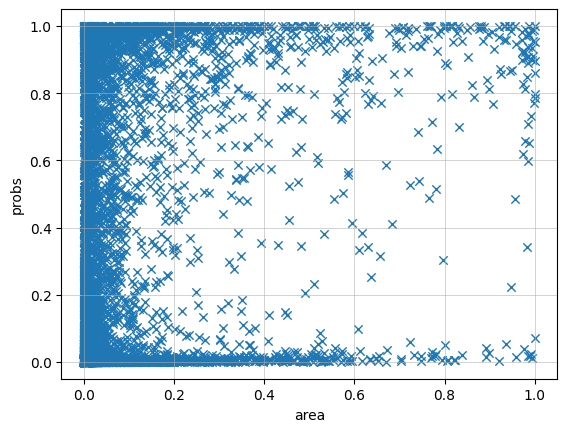

In [17]:
fig, ax = plt.subplots(1)
ax.scatter(area_collect, prob_collect, marker='x', linewidth=1)
ax.set_xlabel("area")
ax.set_ylabel("probs")
ax.grid(linewidth=0.4)
